In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn import metrics

sys.path.append("../src")
from features.feature_engineering import main as import_data
from models.elo import ELO
from models.model_pipeline import main

# Helper Functions

In [2]:
def betting_simulation(df: pd.DataFrame, threshold: float) -> tuple[int, int]:
    """
    Compute the number of bets placed and bets won given a threshold.

    Args:
        df: DataFrame containing columns 'model_predictions', 'home_line', 'result'.
        threshold: Threshold for deciding when to place a bet.

    Returns:
        tuple: (bets_placed, bets_won)
    """
    bets_placed = 0
    bets_won = 0
    for row in df.itertuples():
        if row.model_predictions + threshold < -row.home_line:
            bets_placed += 1
            if row.result < row.home_line:
                bets_won += 1
        elif row.model_predictions > -row.home_line + threshold:
            bets_placed += 1
            if row.result > row.home_line:
                bets_won += 1
    return bets_placed, bets_won


def sweep_thresholds(df: pd.DataFrame, start=0, stop=3.1, step=0.1) -> pd.DataFrame:
    """
    Sweep thresholds to calculate betting accuracy and number of bets placed.

    Args:
        df: Test DataFrame.
        start: Minimum threshold.
        stop: Maximum threshold.
        step: Step size.

    Returns:
        pd.DataFrame: DataFrame with columns: 'threshold', 'accuracy', 'bets_placed'.
    """
    results = []
    for threshold in np.arange(start, stop, step):
        bets_placed, bets_won = betting_simulation(df, threshold)
        accuracy = bets_won / bets_placed if bets_placed > 0 else np.nan
        results.append(
            {"threshold": threshold, "accuracy": accuracy, "bets_placed": bets_placed}
        )
    return pd.DataFrame(results)


def evaluate_model(df: pd.DataFrame) -> dict:
    """
    Compute standard regression metrics for model and Vegas line.

    Args:
        df: DataFrame containing 'result', 'model_predictions', and 'home_line'.

    Returns:
        dict: Dictionary of RMSE, MAE, R2 for model and Vegas line.
    """
    metrics_dict = {
        "model_rmse": metrics.root_mean_squared_error(df["result"], df["model_predictions"]),
        "model_mae": metrics.mean_absolute_error(df["result"], df["model_predictions"]),
        "model_r2": metrics.r2_score(df["result"], df["model_predictions"]),
        "vegas_rmse": metrics.root_mean_squared_error(df["result"], -df["home_line"]),
        "vegas_mae": metrics.mean_absolute_error(df["result"], -df["home_line"]),
        "vegas_r2": metrics.r2_score(df["result"], -df["home_line"]),
    }
    return metrics_dict


def plot_pipeline_results(
    df: pd.DataFrame, results: pd.DataFrame, model, x_train: pd.DataFrame
):
    """
    Plot model evaluation results.

    Args:
        df: Test dataframe containing 'result', 'model_predictions', and 'home_line'.
        results: DataFrame from sweep_thresholds helper function.
        model: Trained model for SHAP analysis.
        x_train: Training feature matrix for SHAP computation.
    """
    # --- Threshold plots ---
    plt.figure(figsize=(8, 4))

    # Accuracy vs Threshold
    plt.subplot(1, 2, 1)
    plt.plot(results["threshold"], results["accuracy"])
    plt.xlabel("Model edge")
    plt.ylabel("Accuracy")
    plt.title("Betting Accuracy vs Threshold")

    # Bets placed vs Threshold
    plt.subplot(1, 2, 2)
    plt.plot(results["threshold"], results["bets_placed"])
    plt.xlabel("Model edge")
    plt.ylabel("Bets placed")
    plt.title("Bets Placed vs Threshold")

    plt.tight_layout()
    plt.show()

    # --- SHAP summary plot ---
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x_train)
    shap.summary_plot(
        shap_values,
        x_train,
        max_display=20,
        plot_type="violin",
        show=True,
        plot_size=[8, 6]
    )

# Import Data

In [3]:
features = [
    # "home_line",
    # "over_under",
    # "home_implied_score",
    # "away_implied_score",

    "week",
    "is_indoors",
    "surface",
    "attendance",

    "elo_diff",

    "home_ats_pctg_5",
    "away_ats_pctg_5",
    "home_ats_pctg_10",
    "away_ats_pctg_10",
    "home_ats_pctg_fav_5",
    "away_ats_pctg_fav_5",
    "home_ats_pctg_fav_10",
    "away_ats_pctg_fav_10",
    "home_ats_pctg_und_5",
    "away_ats_pctg_und_5",
    "home_ats_pctg_und_10",
    "away_ats_pctg_und_10",
    "home_win_pctg_5",
    "away_win_pctg_5",
    "home_win_pctg_10",
    "away_win_pctg_10",
    "home_spread_diff_5",
    "away_spread_diff_5",
    "home_spread_diff_10",
    "away_spread_diff_10",

    "epa_mean_adv_home",
    "epa_mean_adv_away",
    "pbp_exp_points_tot_adv_home",
    "pbp_exp_points_tot_adv_away",
    "pbp_exp_points_pass_adv_home",
    "pbp_exp_points_pass_adv_away",
    "pbp_exp_points_rush_adv_home",
    "pbp_exp_points_rush_adv_away",
    "pbp_exp_points_k_adv",
    "pbp_exp_points_p_adv",
    "pbp_exp_points_fgxp_adv",
    "pbp_exp_points_to_adv_home",
    "pbp_exp_points_to_adv_away",

    "final_score_adv_home",
    "final_score_adv_away",
    "yds_adv",
    "ydsnet_mean_adv_home",
    "ydsnet_mean_adv_away",
    "ydstogo_mean_adv_home",
    "ydstogo_mean_adv_away",
    "drive_nunique_adv_home",
    "drive_nunique_adv_away",
    "third_down_conversions_adv",
    "fourth_down_conversions_adv",

    "pass_yds_net_adv",
    "pass_attempts_adv",
    "pass_cmp_adv",
    "pass_tds_adv",
    "first_down_pass_sum_adv_home",
    "first_down_pass_sum_adv_away",
    "first_down_rush_sum_adv_home",
    "first_down_rush_sum_adv_away",
    "rush_attempts_adv",
    "rush_tds_adv",
    "receiving_yards_mean_adv_home",
    "receiving_yards_mean_adv_away",
    "yards_after_catch_mean_adv_home",
    "yards_after_catch_mean_adv_away",
    "sacks_adv",
    "sack_yards_adv",
    "tackled_for_loss_sum_adv_home",
    "tackled_for_loss_sum_adv_away",
    "fumbles_adv",
    "turnovers_adv",
    "penalties_adv"
]

In [4]:
historical_elos = pd.read_csv("../data/external/historical_elos.csv")
data = import_data(2010, 2024, span=5)
data = ELO(data, historical_elos).data
data[["game_id"] + features].head()

,game_id,week,is_indoors,surface,attendance,elo_diff,home_ats_pctg_5,away_ats_pctg_5,home_ats_pctg_10,away_ats_pctg_10,...,receiving_yards_mean_adv_away,yards_after_catch_mean_adv_home,yards_after_catch_mean_adv_away,sacks_adv,sack_yards_adv,tackled_for_loss_sum_adv_home,tackled_for_loss_sum_adv_away,fumbles_adv,turnovers_adv,penalties_adv
0,20110908_nor_gnb,1,0,0.0,70555.0,99.432,0.8,0.4,0.6,0.5,...,-1.017345,-0.130597,-0.644528,0.474510,1.545098,-0.107843,0.000000,-0.047059,-0.354902,-0.503922
1,20110911_phi_ram,1,1,1.0,56722.0,-135.214,0.4,0.4,0.3,0.5,...,0.238758,-0.129674,0.124182,-0.622549,-2.774510,-0.446078,-0.855392,-0.750000,-0.144608,-1.083333
2,20110911_clt_htx,1,0,0.0,71444.0,-89.304,0.4,0.4,0.3,0.2,...,-1.558328,0.751557,-0.994101,0.666667,5.612745,0.213235,0.017157,0.036765,-0.230392,0.573529
3,20110911_oti_jax,1,0,0.0,61619.0,2.568,0.4,0.4,0.5,0.3,...,-0.460450,0.130539,-1.290698,0.458333,5.000000,-0.958333,0.333333,0.041667,0.166667,-1.875000
4,20110911_pit_rav,1,0,1.0,71434.0,5.454,0.6,0.8,0.5,0.6,...,1.365157,0.876068,0.429875,-0.009747,0.953216,0.325536,0.561404,0.017544,0.048733,-0.545809


# Direct Model

In [5]:
df_train, df_test, model, best_params = main(
    data=data,
    train_seasons=list(range(2011, 2024)),
    test_seasons=[2024],
    features=features,
    model_class="XGB",
    n_trials=50,
    target_type="direct",
    baseline_col=None
)

[I 2025-10-06 18:33:02,806] A new study created in memory with name: no-name-1713b032-c17c-46ed-a98f-32dc83add62b
[I 2025-10-06 18:33:05,505] Trial 0 finished with value: 13.334262604280806 and parameters: {'max_depth': 6, 'min_child_weight': 6, 'subsample': 0.8687131700711338, 'colsample_bynode': 0.5969776856696049, 'reg_lambda': 2.206969727980661, 'learning_rate': 0.0656233504575106}. Best is trial 0 with value: 13.334262604280806.
[I 2025-10-06 18:33:07,620] Trial 1 finished with value: 13.219865013412745 and parameters: {'max_depth': 4, 'min_child_weight': 20, 'subsample': 0.9789914538400472, 'colsample_bynode': 0.9150521780177852, 'reg_lambda': 1.8216487661410963, 'learning_rate': 0.06025737169838162}. Best is trial 1 with value: 13.219865013412745.
[I 2025-10-06 18:33:08,910] Trial 2 finished with value: 13.260452497429506 and parameters: {'max_depth': 3, 'min_child_weight': 12, 'subsample': 0.6689056607250676, 'colsample_bynode': 0.5161435739500743, 'reg_lambda': 0.0022106253123

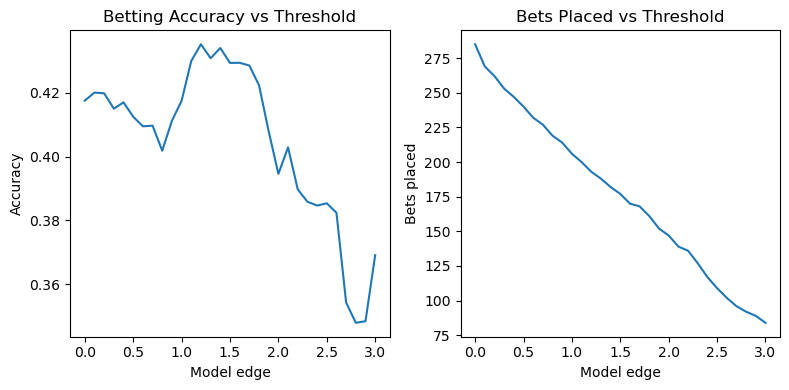

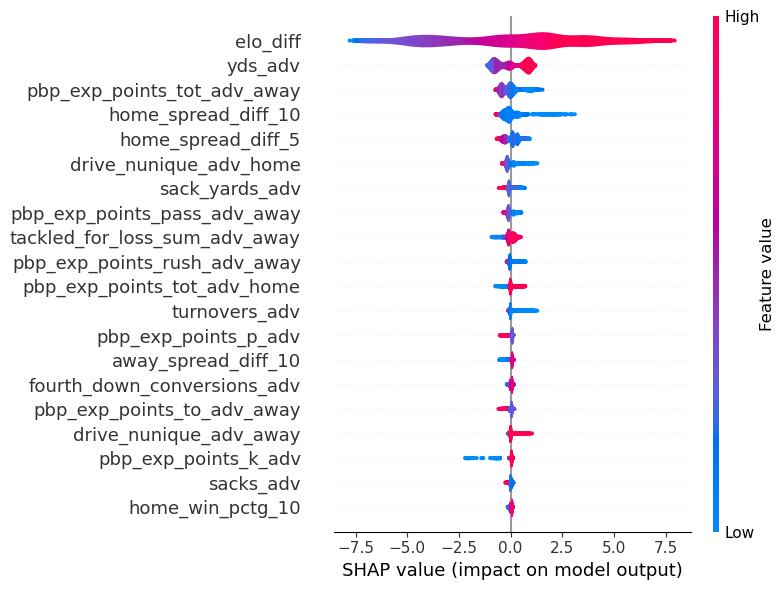

{'model_rmse': 13.10590244332396,
 'model_mae': 9.952716766167105,
 'model_r2': 0.17024998388802393,
 'vegas_rmse': 12.674224430405227,
 'vegas_mae': 9.829824561403509,
 'vegas_r2': 0.22400987581689857}

In [6]:
results = sweep_thresholds(df_test)
plot_pipeline_results(df_test, results, model, df_train[features])
evaluate_model(df_test)

# Residual Model

In [7]:
df_train, df_test, model, best_params = main(
    data=data,
    train_seasons=list(range(2011, 2024)),
    test_seasons=[2024],
    features=features,
    model_class="XGB",
    n_trials=50,
    target_type="residual",
    baseline_col="home_line"
)

[I 2025-10-06 18:35:39,336] A new study created in memory with name: no-name-36008222-3fa1-4e12-ab2f-e5525fe93620
[I 2025-10-06 18:35:45,410] Trial 0 finished with value: 14.321397076562842 and parameters: {'max_depth': 5, 'min_child_weight': 7, 'subsample': 0.6253264782062135, 'colsample_bynode': 0.895317500373775, 'reg_lambda': 13.694617991472375, 'learning_rate': 0.024470845437017674}. Best is trial 0 with value: 14.321397076562842.
[I 2025-10-06 18:35:47,338] Trial 1 finished with value: 14.495768686263979 and parameters: {'max_depth': 5, 'min_child_weight': 12, 'subsample': 0.5881466947624472, 'colsample_bynode': 0.8185555178838964, 'reg_lambda': 0.027427019780124434, 'learning_rate': 0.16007472876860349}. Best is trial 0 with value: 14.321397076562842.
[I 2025-10-06 18:36:01,551] Trial 2 finished with value: 14.420790176047847 and parameters: {'max_depth': 12, 'min_child_weight': 6, 'subsample': 0.8648246614222392, 'colsample_bynode': 0.5943300836735637, 'reg_lambda': 0.667797614

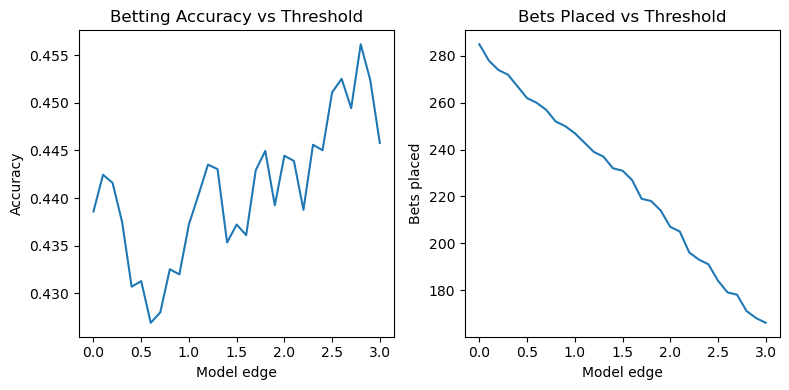

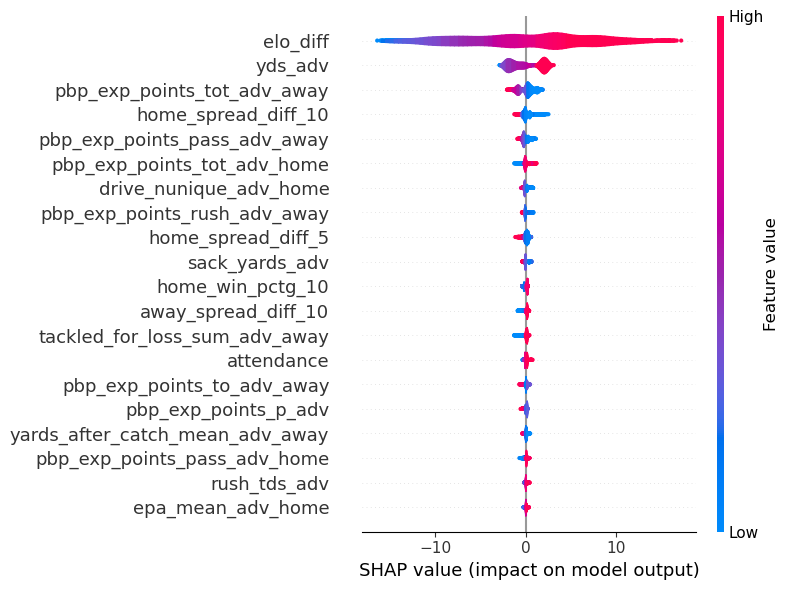

{'model_rmse': 14.195774264523576,
 'model_mae': 10.728623482702593,
 'model_r2': 0.026509814792172293,
 'vegas_rmse': 12.674224430405227,
 'vegas_mae': 9.829824561403509,
 'vegas_r2': 0.22400987581689857}

In [8]:
results = sweep_thresholds(df_test)
plot_pipeline_results(df_test, results, model, df_train[features])
evaluate_model(df_test)